In [36]:
import sys
sys.path.append("../src")
from connect_db import get_engine

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
engine = get_engine()

# Delivery Analysis 

In [39]:
delivery_df = pd.read_sql(
    "SELECT * FROM vw_delivery_analysis",
    engine
)

In [40]:
delivery_df.head()

,order_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,delivery_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-18,2017-10-10 21:25:13,8,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-13,2018-08-07 15:27:45,14,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-09-04,2018-08-17 18:06:29,9,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-15,2017-12-02 00:28:42,14,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-26,2018-02-16 18:17:02,3,0


In [41]:
delivery_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96476 entries, 0 to 96475
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96476 non-null  object        
 1   order_purchase_timestamp       96476 non-null  datetime64[ns]
 2   order_estimated_delivery_date  96476 non-null  datetime64[ns]
 3   order_delivered_customer_date  96476 non-null  datetime64[ns]
 4   delivery_days                  96476 non-null  int64         
 5   is_late                        96476 non-null  int64         
dtypes: datetime64[ns](3), int64(2), object(1)
memory usage: 4.4+ MB


In [42]:
delivery_df.shape

(96476, 6)

In [43]:
avg_delivery_time = delivery_df["delivery_days"].mean()
print(f"Average Delivery Time: {avg_delivery_time:.2f} days")

Average Delivery Time: 12.50 days


In [44]:
median_delivery_time = delivery_df["delivery_days"].median()
print(f"Median Delivery Time: {median_delivery_time:.2f} days")

Median Delivery Time: 10.00 days


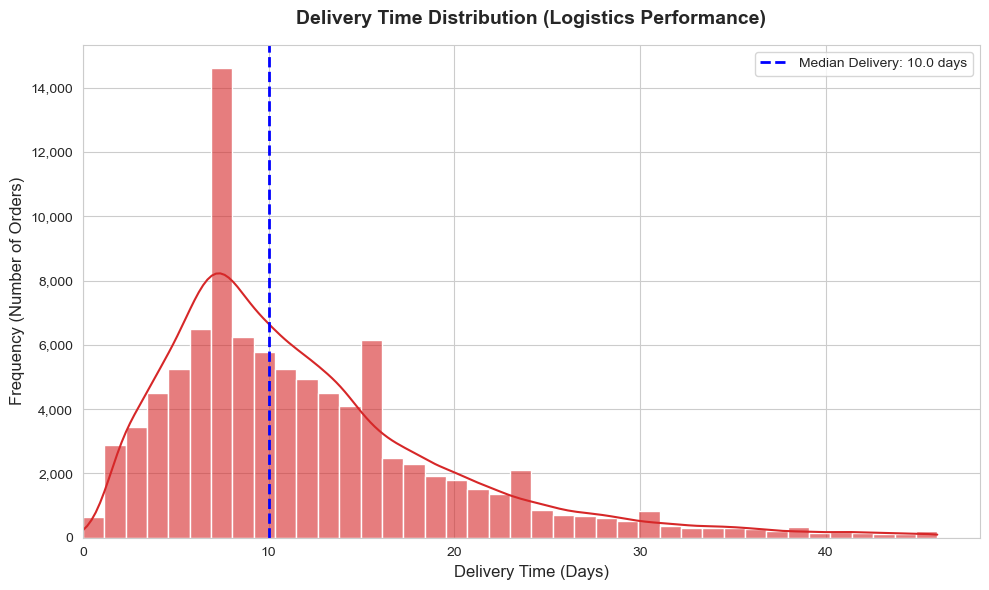

In [45]:
limit_days = delivery_df["delivery_days"].quantile(0.99)
filtered_df = delivery_df[delivery_df["delivery_days"] <= limit_days]
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=filtered_df,
    x="delivery_days",
    bins=40,
    kde=True,
    color="#d62728",
    alpha=0.6
)
plt.ticklabel_format(style='plain', axis='both')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
median_days = delivery_df["delivery_days"].median()
plt.axvline(median_days, color='blue', linestyle='--', linewidth=2, 
            label=f'Median Delivery: {median_days:.1f} days')
plt.title("Delivery Time Distribution (Logistics Performance)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Delivery Time (Days)", fontsize=12)
plt.ylabel("Frequency (Number of Orders)", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.xlim(0, filtered_df['delivery_days'].max() * 1.05)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Phân bổ Thời gian Giao hàng (Delivery Time Distribution - Logistics Performance)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột tần suất (Histogram) kết hợp đường ước lượng mật độ nhân (KDE line) nhằm thể hiện mật độ phân phối liên tục.
* **Tiêu đề:** Delivery Time Distribution (Logistics Performance) - Phân bổ thời gian giao hàng (Hiệu suất Logistics).
* **Trục hoành (X-axis):** Delivery Time (Days) - Thời gian giao hàng tính bằng ngày (kéo dài từ 0 đến hơn 45 ngày).
* **Trục tung (Y-axis):** Frequency (Number of Orders) - Tần suất xuất hiện tính bằng số lượng đơn hàng (dao động từ mốc 0 đến hơn 14,000 đơn).
* **Đường chỉ số đặc biệt:** Đường nét đứt màu xanh dương thể hiện giá trị trung vị (Median Delivery) ở mốc **10.0 ngày**.

---

## 2. Các Quan sát Thống kê từ Biểu đồ

* **Cột tần suất cao nhất (Chạm đỉnh đồ thị):** Nằm ở khung khoảng **7 - 8 ngày** với số lượng đơn hàng vượt mốc **14,000 đơn**. Đây là khoảng thời gian giao hàng phổ biến nhất (Mode) của hệ thống logistics này.
* **Vị trí đường Trung vị (Median):** Đường nét đứt màu xanh cắt chính xác tại mốc **10.0 ngày**. Điều này có nghĩa là 50% tổng số đơn hàng được giao thành công trong vòng dưới 10 ngày, và 50% số đơn hàng còn lại mất nhiều hơn 10 ngày để đến tay người nhận.
* **Các điểm nhô cao bất thường (Minor Peaks):** Ngoài đỉnh chính ở ngày 7-8, đồ thị còn xuất hiện hai cột nhô cao rõ rệt ở mốc **15 ngày** (~6,000 đơn) và **24 ngày** (~2,000 đơn). Điều này thường do các đơn hàng rơi vào các mốc thời gian cố định như giao hàng liên vùng hoặc đơn bị lưu kho định kỳ tại trạm trung chuyển.

---

## 3. Nhận xét và Đánh giá Hình dạng Phân phối (Insights)

* **Phân phối lệch phải có độ dốc dài (Right-Skewed / Long-Tailed Distribution):**
  * Đồ thị có phần đuôi (tail) kéo dài rất sâu về phía bên phải, kéo dài từ ngày 20 đến tận hơn 45 ngày. 
  * **Đánh giá hiệu suất vận hành:** Mặc dù phần lớn đơn hàng được xử lý tốt và giao trong khoảng 5 - 15 ngày, nhưng phần đuôi dài chứng tỏ hệ thống đang gặp vấn đề kiểm soát đối với nhóm đơn hàng bị trễ hạn (Delayed orders). Những đơn hàng mất từ 30 đến 45 ngày mới giao tới nơi chính là điểm nghẽn (bottleneck) gây ảnh hưởng nghiêm trọng đến trải nghiệm và mức độ hài lòng của khách hàng (Customer Satisfaction).
  * Với kiểu phân phối lệch phải này, giá trị thời gian giao hàng trung bình (Mean) chắc chắn sẽ bị kéo lên cao hơn mốc trung vị 10 ngày do chịu ảnh hưởng từ những đơn hàng bị giao siêu trễ phía cuối đồ thị.

In [46]:
late_orders = delivery_df["is_late"].sum()
total_orders = len(delivery_df)
late_percentage = ( late_orders/total_orders) * 100
print( f"Late Delivery Rate: {late_percentage:.2f}%")

Late Delivery Rate: 8.11%


In [47]:
late_summary = (delivery_df["is_late"].value_counts().reset_index())
late_summary.columns = ["is_late","count"]

In [48]:
late_summary["status"] = (late_summary["is_late"].map({0: "On Time",1: "Late"}))

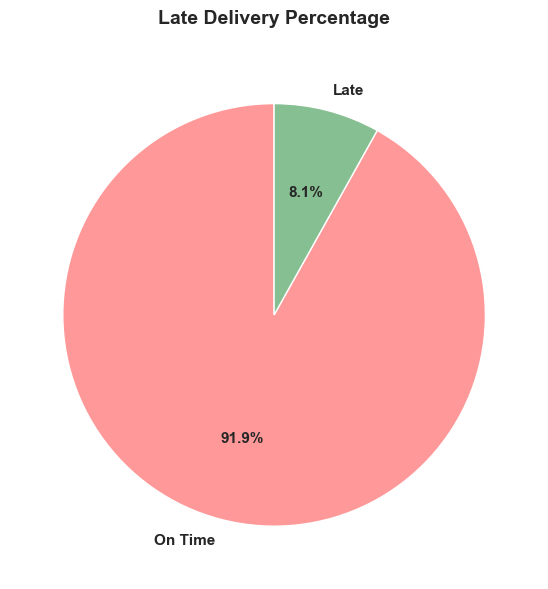

In [49]:
colors = ['#ff9999', '#86bf91', '#aec7e8', '#ffbb78']
plt.figure(figsize=(6, 6))
plt.pie(
    late_summary["count"],
    labels=late_summary["status"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors[:len(late_summary)],
    textprops={'fontsize': 11, 'weight': 'bold'}
)
plt.title("Late Delivery Percentage", fontsize=14, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Tỷ lệ Giao hàng Trễ hạn (Late Delivery Percentage)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python tính toán dựa trên cột bô-lean/số nguyên `is_late` trong DataFrame `delivery_df` để xác định tỷ lệ phần trăm trễ hạn tổng thể. Tiếp theo, sử dụng hàm `.value_counts()` và mã hóa nhãn (`0: "On Time"`, `1: "Late"`) để chuẩn bị dữ liệu vẽ hình.
* **Loại biểu đồ:** Biểu đồ tròn (Pie chart) hiển thị tỷ lệ phần trăm trực quan cho từng trạng thái giao hàng.
* **Tiêu đề:** Late Delivery Percentage (Tỷ lệ phần trăm giao hàng trễ).

---

## 2. Số liệu Chi tiết từ Mã nguồn và Biểu đồ
Kết quả tính toán logic và hiển thị trực quan ghi nhận các chỉ số chính xác như sau:
* **Late Delivery Rate (Tỷ lệ trễ hạn chính xác từ console):** **8.11%** (Biểu đồ tròn làm tròn hiển thị: **8.1%**, tương ứng với phần quạt màu xanh lá).
* **On Time Rate (Tỷ lệ đúng hạn):** **91.89%** (Biểu đồ tròn làm tròn hiển thị: **91.9%**, tương ứng với phần quạt màu đỏ/hồng chiếm đa số).

---

## 3. Nhận xét và Đánh giá (Insights)

* **Hiệu suất Logistics ở mức khá tốt nhưng vẫn còn dư địa cải thiện:**
  * Hệ thống ghi nhận tỷ lệ giao hàng đúng hạn rất cao, đạt **91.9%**. Phần lớn đơn hàng đã tuân thủ đúng cam kết thời gian quy định, tạo nền tảng tin cậy cho dịch vụ khách hàng.
  * Tuy nhiên, tỷ lệ trễ hạn **8.11%** (khoảng 8 đơn hàng bị trễ trên mỗi 100 đơn phát đi) vẫn là một con số cần lưu tâm đối với một hệ thống vận hành chuyên nghiệp. 

* **Mối liên hệ với phân bổ phân phối trước đó:**
  * Chỉ số 8.11% này chính là lời giải thích định lượng cho phần "đuôi dài lệch phải" (Long tail) kéo dài từ 20 đến hơn 45 ngày ở biểu đồ *Delivery Time Distribution* trước đó. Nhóm 8.11% đơn hàng bị dán nhãn `Late` này chính là tác nhân trực tiếp làm giảm điểm trải nghiệm người dùng, cần được bóc tách sâu hơn theo vùng địa lý hoặc đơn vị vận chuyển để tìm ra nguyên nhân cốt lõi.

---



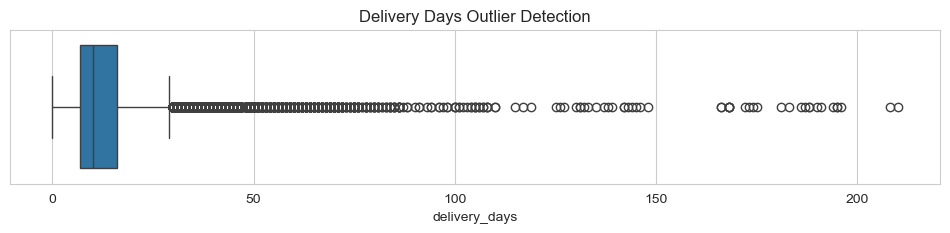

In [50]:
plt.figure(figsize=(12,2))
sns.boxplot(
    x=delivery_df["delivery_days"]
)
plt.title(
    "Delivery Days Outlier Detection"
)
plt.show()

In [51]:
Q1 = delivery_df[ "delivery_days"].quantile(0.25)
Q3 = delivery_df["delivery_days"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = ( Q1 - 1.5 * IQR)
upper_bound = ( Q3 + 1.5 * IQR)
delivery_outliers = delivery_df[(delivery_df["delivery_days"] < lower_bound) |( delivery_df["delivery_days"] > upper_bound)]

In [52]:
print(f"Number of Outliers: {len(delivery_outliers):,}")

Number of Outliers: 4,732


In [53]:
print(f"Outlier Percentage: {len(delivery_outliers)/len(delivery_df)*100:.2f}%")

Outlier Percentage: 4.90%


In [54]:
delivery_df["delivery_group"] = pd.cut(
    delivery_df["delivery_days"],
    bins=[0, 7,14,21,30,999],
    labels=["0-7 Days","8-14 Days","15-21 Days","22-30 Days",">30 Days"]
)

In [55]:
delivery_group = (delivery_df["delivery_group"] .value_counts() .sort_index())

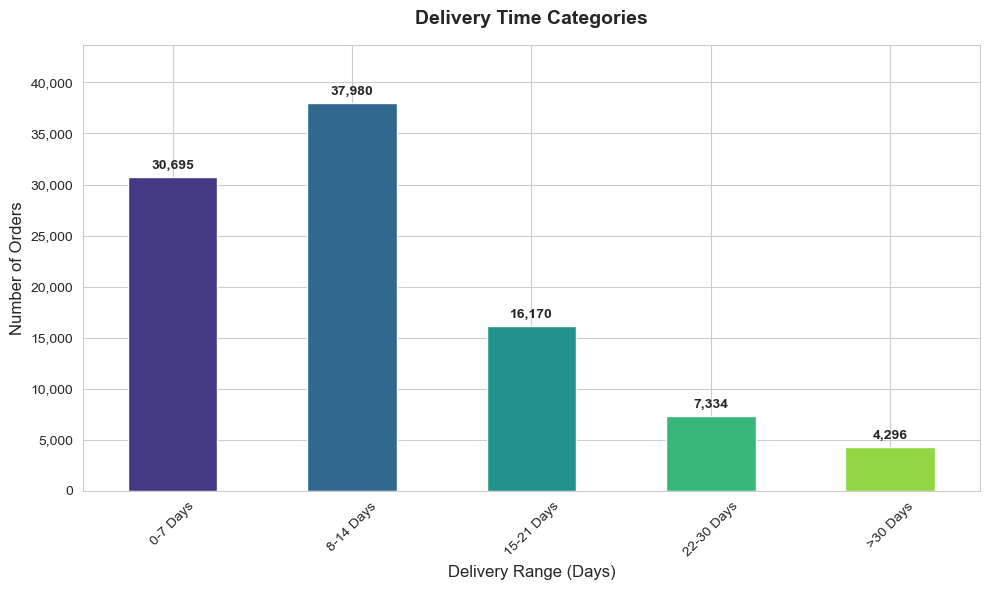

In [56]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(delivery_group))
ax = delivery_group.plot(kind="bar", color=colors, rot=45)
plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:,.0f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("Delivery Time Categories", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Delivery Range (Days)", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.ylim(0, delivery_group.max() * 1.15)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Phân nhóm Thời gian Giao hàng (Delivery Time Categories)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python tiến hành rời rạc hóa (Binning) biến liên tục `delivery_days` bằng hàm `pd.cut()`. Dữ liệu được chia thành 5 khoảng (bins) cố định: `[0, 7, 14, 21, 30, 999]` với các nhãn tương ứng. Sau đó dùng `.value_counts().sort_index()` để thống kê số lượng đơn hàng theo đúng thứ tự phân lớp.
* **Loại biểu đồ:** Biểu đồ cột đứng (Bar chart) có hiển thị nhãn giá trị số lượng đơn hàng chính xác trên đầu mỗi cột.
* **Tiêu đề:** Delivery Time Categories (Các nhóm thời gian giao hàng).
* **Trục tung (Y-axis):** Number of Orders - Số lượng đơn hàng (dao động từ mốc 0 đến 40,000 đơn).
* **Trục hoành (X-axis):** Delivery Range (Days) - Khung thời gian giao hàng đã được phân lớp.

---

## 2. Số liệu Chi tiết từ Biểu đồ
Hệ thống ghi nhận số lượng đơn hàng chính xác rơi vào từng nhóm thời gian như sau:
* **0-7 Days (Dưới 1 tuần):** 30,695 đơn hàng
* **8-14 Days (Từ 1 đến 2 tuần):** 37,980 đơn hàng *(Nhóm chiếm đa số)*
* **15-21 Days (Từ 2 đến 3 tuần):** 16,170 đơn hàng
* **22-30 Days (Từ 3 tuần đến 1 tháng):** 7,334 đơn hàng
* **>30 Days (Trên 1 tháng):** 4,296 đơn hàng

---

## 3. Nhận xét và Đánh giá (Insights)

* **Năng lực xử lý chính nằm trong khoảng 2 tuần đầu (Khung tối ưu):**
  * Hai nhóm **0-7 Days** (30,695 đơn) và **8-14 Days** (37,980 đơn) chiếm tỷ trọng áp đảo hoàn toàn trên biểu đồ. 
  * Điều này cho thấy phần lớn đơn hàng của doanh nghiệp (hơn 68,000 đơn) được xử lý và giao thành công tới tay khách hàng rất nhanh chóng, chỉ trong vòng 2 tuần đổ lại. Khung **8-14 Days** chính là điểm rơi phổ biến nhất của hệ thống giao vận hiện tại.

* **Diện mạo rõ ràng của nhóm giao hàng trễ hạn (>22 ngày):**
  * Biểu đồ phân lớp này đã giúp làm rõ nét hơn con số 8.11% đơn hàng trễ thu được từ phân tích trước đó. 
  * Nhóm đơn hàng có thời gian vận chuyển kéo dài từ 3 tuần cho đến hơn 1 tháng chiếm số lượng đáng kể: **7,334 đơn** (khung 22-30 ngày) và **4,296 đơn** (khung trên 30 ngày). Hơn 4,000 đơn hàng phải mất trên 1 tháng mới hoàn thành chính là nhóm rủi ro cao nhất, gây ảnh hưởng tiêu cực đến dịch vụ chăm sóc khách hàng và cần có biện pháp tối ưu tuyến đường hoặc đổi đơn vị vận chuyển đối với các khu vực này.

---



C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_22056\1509782847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


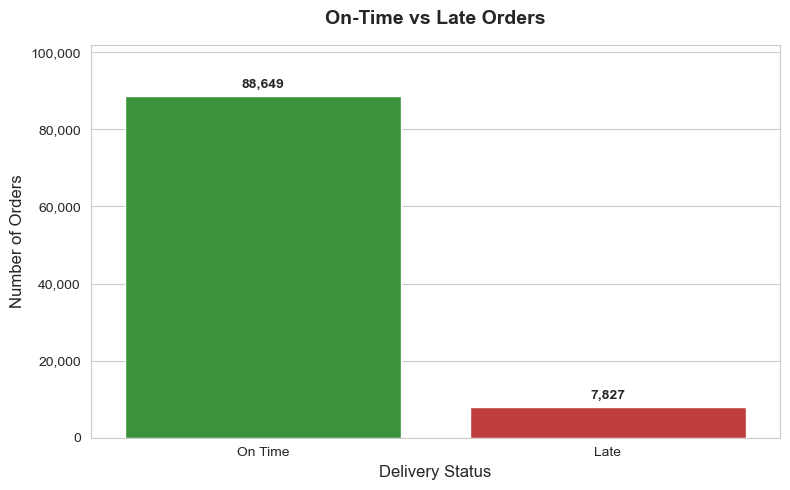

In [57]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=delivery_df,
    x="is_late",
    palette=["#2ca02c", "#d62728"]
)
plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
plt.xticks(ticks=[0, 1], labels=["On Time", "Late"])
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:,.0f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("On-Time vs Late Orders", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Delivery Status", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.ylim(0, delivery_df["is_late"].value_counts().max() * 1.15)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Trạng thái Đơn hàng Đúng hạn và Trễ hạn (On-Time vs Late Orders)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột đứng (Bar chart) có hiển thị nhãn giá trị số lượng đơn hàng chính xác trên đầu mỗi cột.
* **Tiêu đề:** On-Time vs Late Orders (Đơn hàng đúng hạn so với trễ hạn).
* **Trục tung (Y-axis):** Number of Orders - Số lượng đơn hàng (dao động từ mốc 0 đến 100,000 đơn).
* **Trục hoành (X-axis):** Delivery Status - Trạng thái giao hàng (On Time, Late).

---

## 2. Số liệu Chi tiết từ Biểu đồ
Biểu đồ hiển thị chính xác số lượng đơn hàng của từng trạng thái giao vận như sau:
* **On Time (Đúng hạn):** 88,649 đơn hàng.
* **Late (Trễ hạn):** 7,827 đơn hàng.

---

## 3. Nhận xét và Đánh giá (Insights)

* **Năng lực đáp ứng dịch vụ duy trì ở mức cao:**
  * Khối lượng đơn hàng giao đúng hạn chiếm tỷ trọng áp đảo tuyệt đối với **88,649 đơn**, chứng tỏ luồng xử lý và vận chuyển chính của doanh nghiệp đang hoạt động rất trơn tru và hiệu quả.

* **Kiểm soát rủi ro từ nhóm trễ hạn:**
  * Nhóm đơn hàng bị dán nhãn trễ hạn dừng lại ở con số **7,827 đơn**. 
  * **Sự cải thiện về mặt trực quan hóa:** Khác với biểu đồ tròn (Pie chart) trước đó khi dùng màu xanh cho lệnh trễ, biểu đồ này đã chuẩn hóa lại quy ước màu sắc rất chính xác và dễ nhìn: Sử dụng **màu Xanh lá (Green) cho On Time** (Thể hiện sự an toàn/hoàn thành tốt) và **màu Đỏ (Red) cho Late** (Thể hiện sự cảnh báo/rủi ro). Cách phối màu này giúp người xem ngay lập tức nhận diện được vùng dữ liệu cần tối ưu mà không bị nhầm lẫn.

# Review Analysis 

In [58]:
review_df = pd.read_sql(
    "SELECT * FROM vw_review_analysis",
    engine
)

In [59]:
review_df.head()

,review_score,category_name
0,5,cool_stuff
1,4,pet_shop
2,5,furniture_decor
3,4,perfumery
4,5,garden_tools


In [60]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112372 entries, 0 to 112371
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   review_score   112372 non-null  int64 
 1   category_name  112372 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.7+ MB


In [61]:
review_df.shape

(112372, 2)

In [62]:
avg_rating = review_df["review_score"].mean()
print(f"Average Rating: {avg_rating:.2f}/5")

Average Rating: 4.03/5


In [63]:
median_rating = review_df["review_score"].median()
print(f"Median Rating: {median_rating:.2f}/5")

Median Rating: 5.00/5


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_22056\4101822338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


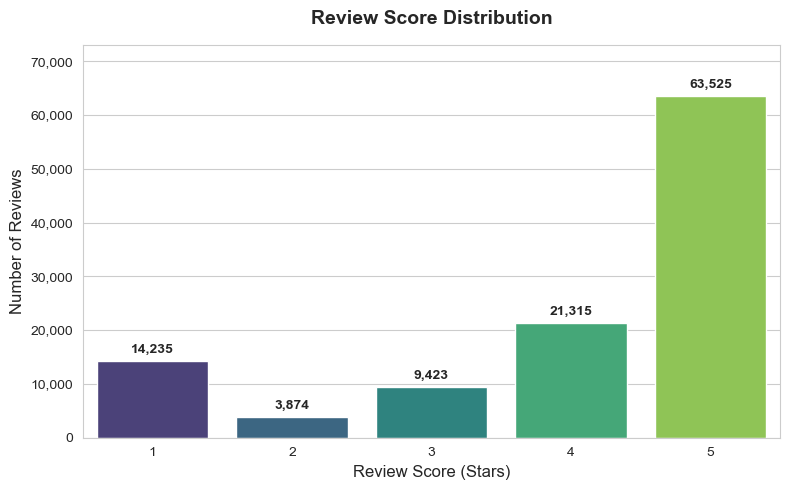

In [64]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=review_df,
    x="review_score",
    palette="viridis"
)
plt.ticklabel_format(style='plain', axis='y')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:,.0f}", 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("Review Score Distribution", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Review Score (Stars)", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.ylim(0, review_df["review_score"].value_counts().max() * 1.15)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Phân bổ Điểm đánh giá từ Khách hàng (Review Score Distribution)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột đứng (Bar chart) có hiển thị nhãn giá trị số lượng đánh giá chính xác trên đầu mỗi cột.
* **Tiêu đề:** Review Score Distribution (Phân bổ điểm đánh giá).
* **Trục tung (Y-axis):** Number of Reviews - Số lượng lượt đánh giá (dao động từ mốc 0 đến 70,000 lượt).
* **Trục hoành (X-axis):** Review Score (Stars) - Số sao đánh giá (từ 1 sao đến 5 sao).

---

## 2. Số liệu Chi tiết từ Biểu đồ
Biểu đồ ghi nhận số lượng lượt đánh giá chính xác cho từng mức điểm sao như sau:
* **1 sao:** 14,235 lượt
* **2 sao:** 3,874 lượt
* **3 sao:** 9,423 lượt
* **4 sao:** 21,315 lượt
* **5 sao:** 63,525 lượt

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

* **Sự hài lòng cao chiếm tỷ trọng áp đảo (Phân phối lệch trái):**
  * Biểu đồ thể hiện hình thái phân phối lệch trái (Left-skewed distribution) rất rõ ràng. Nhóm khách hàng hài lòng tối đa (**5 sao**) đạt con số khổng lồ với **63,525 lượt**, chiếm phần lớn tổng số lượng đánh giá trên hệ thống.
  * Nếu cộng gộp nhóm phản hồi tích cực (**4 sao và 5 sao**), doanh nghiệp ghi nhận tổng cộng **84,840 lượt** đánh giá tốt, cho thấy chất lượng sản phẩm và dịch vụ nhìn chung đáp ứng rất tốt kỳ vọng của đại đa số người tiêu dùng.

* **Bất thường từ phân khúc đánh giá tiêu cực (Tâm lý phản hồi cực đoan):**
  * Điểm biến động đáng chú ý nhất về mặt hành vi khách hàng nằm ở nhóm điểm thấp: **Lượng đánh giá 1 sao (14,235 lượt) cao gấp gần 3.7 lần lượng đánh giá 2 sao (3,874 lượt)**. 
  * Đây là hiện tượng tâm lý cực kỳ phổ biến trong thương mại điện tử (J-shaped distribution). Khi khách hàng gặp trải nghiệm không tốt, họ có xu hướng để lại đánh giá tệ nhất có thể (1 sao) để thể hiện sự thất vọng tột độ, thay vì cân nhắc chấm mức trung dung là 2 sao.

* **Mối liên hệ logic với hiệu suất vận chuyển:**
  * Con số **14,235 lượt đánh giá 1 sao** phản ánh một lượng khách hàng không nhỏ đang không hài lòng. Điều này có sự tương quan mật thiết với báo cáo logistics trước đó (ghi nhận có **7,827 đơn hàng bị giao trễ** và hơn 4,000 đơn phải chờ trên 1 tháng). Thời gian giao hàng quá lâu rất có thể chính là một trong những nguyên nhân cốt lõi đẩy lượng đánh giá 1 sao lên cao như vậy.

In [65]:
rating_pct = (
    review_df["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)
rating_pct

review_score
1    12.667746
2     3.447478
3     8.385541
4    18.968248
5    56.530986
Name: proportion, dtype: float64

In [66]:
rating_by_category = (review_df
    .groupby("category_name")["review_score"]
    .mean()
    .reset_index()
)

In [67]:
rating_by_category.head()

,category_name,review_score
0,Unknown,3.832922
1,agro_industry_and_commerce,4.000000
2,air_conditioning,3.969178
3,art,3.937198
4,arts_and_craftmanship,4.125000


In [73]:
category_stats = (review_df
    .groupby("category_name")
    .agg(
        avg_rating=("review_score","mean"),
        review_count=("review_score","count")
    )
    .reset_index()
)

category_stats = category_stats[category_stats["review_count"] >= 50]
top_rated = (category_stats.sort_values( "avg_rating",ascending=False).head(10))
top_rated

,category_name,avg_rating,review_count
9,books_general_interest,4.446266,549
23,costruction_tools_tools,4.444444,99
10,books_imported,4.400000,60
11,books_technical,4.368421,266
38,food_drink,4.315412,279
54,luggage_accessories,4.315257,1088
65,small_appliances_home_oven_and_coffee,4.302632,76
32,fashion_shoes,4.233716,261
37,food,4.218182,495
14,cine_photo,4.205479,73


C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_22056\1550217754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


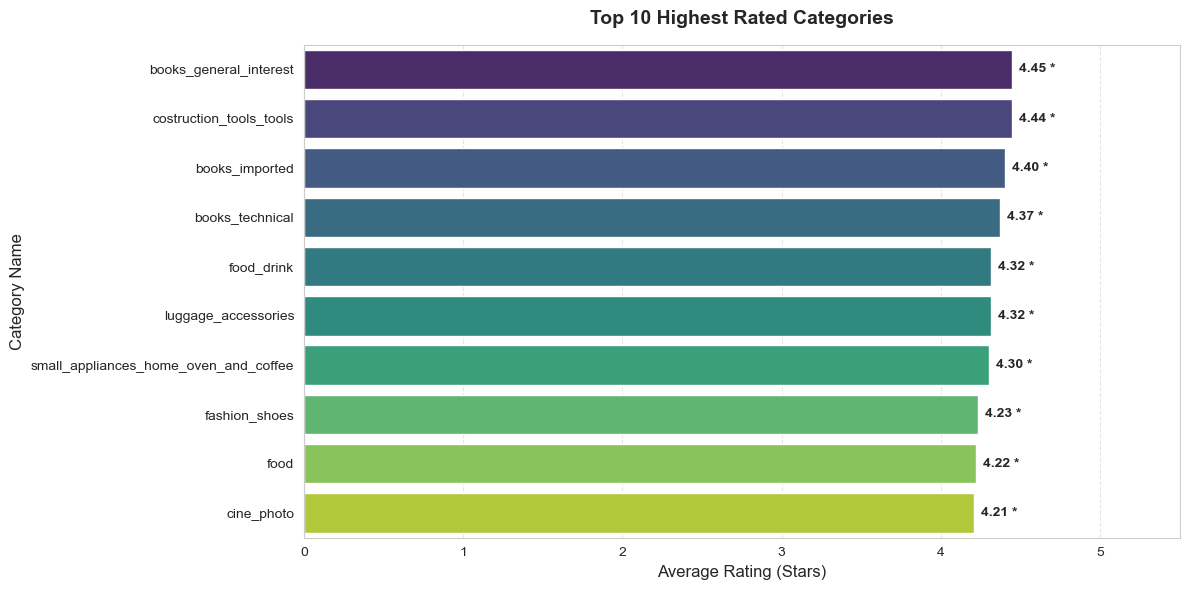

In [75]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_rated,
    x="avg_rating",
    y="category_name",
    palette="viridis"
)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{width:.2f} *", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("Top 10 Highest Rated Categories", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Average Rating (Stars)", fontsize=12)
plt.ylabel("Category Name", fontsize=12)
plt.xlim(0, 5.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [76]:
lowest_rated = (category_stats.sort_values("avg_rating",ascending=True).head(10))

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_22056\2174302397.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


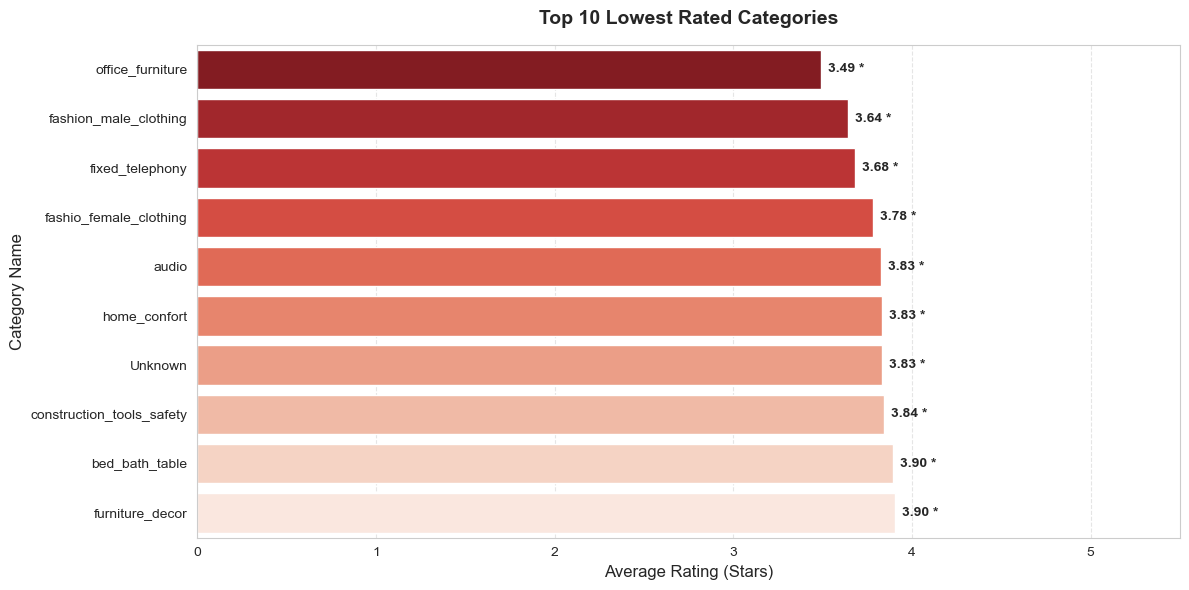

In [80]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=lowest_rated,
    x="avg_rating",
    y="category_name",
    palette="Reds_r"
)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{width:.2f} *", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("Top 10 Lowest Rated Categories", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Average Rating (Stars)", fontsize=12)
plt.ylabel("Category Name", fontsize=12)
plt.xlim(0, 5.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Chất lượng Danh mục Sản phẩm qua Điểm đánh giá (Top 10 Highest vs Lowest Rated Categories)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột ngang (Horizontal Bar chart) thể hiện giá trị điểm đánh giá trung bình kèm theo ký tự đặc biệt (`*`).
* **Trục hoành (X-axis):** Average Rating (Stars) - Số sao đánh giá trung bình (dao động từ mốc 0 đến 5 sao).
* **Trục tung (Y-axis):** Category Name - Tên các danh mục ngành hàng.
* **Quy ước màu sắc trực quan:** * Biểu đồ nhóm Cao nhất sử dụng dải màu lạnh (`viridis`) từ tím đậm đến xanh vàng thể hiện sự tích cực.
  * Biểu đồ nhóm Thấp nhất sử dụng dải màu ấm từ đỏ đậm đến hồng nhạt thể hiện sự cảnh báo/tiêu cực.

---

## 2. Số liệu Chi tiết từ Biểu đồ

### Top 10 Danh mục có Điểm đánh giá Cao nhất
1. **books_general_interest:** 4.45 sao
2. **construction_tools_tools:** 4.44 sao 
3. **books_imported:** 4.40 sao
4. **books_technical:** 4.37 sao
5. **food_drink:** 4.32 sao
6. **luggage_accessories:** 4.32 sao
7. **small_appliances_home_oven_and_coffee:** 4.30 sao
8. **fashion_shoes:** 4.23 sao
9. **food:** 4.22 sao
10. **cine_photo:** 4.21 sao

### Top 10 Danh mục có Điểm đánh giá Thấp nhất
1. **office_furniture:** 3.49 sao *(Thấp nhất toàn sàn)*
2. **fashion_male_clothing:** 3.64 sao
3. **fixed_telephony:** 3.68 sao
4. **fashion_female_clothing:** 3.78 sao
5. **audio:** 3.83 sao
6. **home_confort:** 3.83 sao 
7. **Unknown:** 3.83 sao
8. **construction_tools_safety:** 3.84 sao
9. **bed_bath_table:** 3.90 sao
10. **furniture_decor:** 3.90 sao

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Ngành Sách chiếm vị thế độc tôn về mức độ hài lòng
* Nhóm sản phẩm về **Sách** (`books_general_interest` - 4.45, `books_imported` - 4.40, `books_technical` - 4.37) chiếm tới 3 vị trí trong top 4 ngành hàng có điểm đánh giá cao nhất. Điều này cho thấy chất lượng nội dung, khâu đóng gói và kỳ vọng của khách hàng đối với mặt hàng văn hóa phẩm này đang được đáp ứng vô cùng xuất sắc.

### Cảnh báo nghiêm trọng từ nhóm hàng Thời trang và Nội thất văn phòng
* **office_furniture** là điểm đen lớn nhất trên toàn bộ hệ thống khi tụt sâu xuống mức **3.49 sao**. Đây là mức điểm rất thấp đối với một sàn TMĐT, báo hiệu lỗi nghiêm trọng về chất lượng sản phẩm (bị hỏng hóc, sai lệch mô tả) hoặc gặp khó khăn lớn trong khâu vận chuyển cồng kềnh.
* Phân khúc **Thời trang** cũng gặp khủng hoảng về mức độ hài lòng khi cả đồ nam (`fashion_male_clothing` - 3.64) và đồ nữ (`fashion_female_clothing` - 3.78) đều bị kéo vào nhóm bét bảng. Vấn đề của ngành thời trang thông thường nằm ở việc sai lệch kích cỡ (size) hoặc chất liệu vải không như ảnh quảng cáo.

### Bẫy vận hành của sản phẩm cốt lõi (Trường hợp bed_bath_table)
* Một insight đặc biệt quan trọng xuất hiện khi đối chiếu với các báo cáo trước: Danh mục **bed_bath_table** (Chăn ga gối nệm) vốn là ngành hàng **vô địch về khối lượng bán ra (11,115 sản phẩm)** và đứng thứ ba về doanh thu, nhưng lại nằm trong **Top 10 ngành hàng nhận đánh giá thấp nhất (3.90 sao)**.
* **Đánh giá rủi ro:** Việc một ngành hàng chủ lực bán được rất nhiều đơn nhưng điểm sao trung bình không nổi 4.0 là một dấu hiệu cực kỳ nguy hiểm. Khối lượng đơn quá lớn có thể đã làm quá tải quy trình kiểm tra chất lượng (QC) hoặc gây nghẽn khâu giao vận, trực tiếp tạo ra lượng lớn đánh giá 1 sao (như đã thấy ở biểu đồ phân phối trước). Doanh nghiệp cần ưu tiên chấn chỉnh ngay chất lượng cung ứng của danh mục này để tránh rủi ro mất thị phần dài hạn.

In [81]:
most_reviewed = (category_stats.sort_values( "review_count", ascending=False).head(10))

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_22056\2700828895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


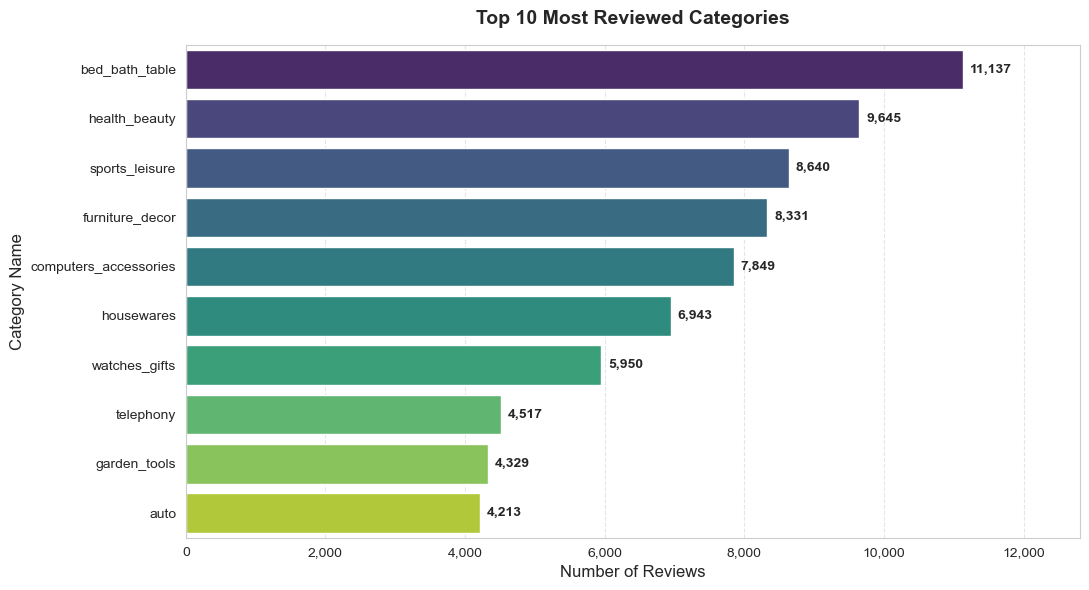

In [83]:
sns.set_style("whitegrid")
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=most_reviewed,
    x="review_count",
    y="category_name",
    palette="viridis"
)
plt.ticklabel_format(style='plain', axis='x')
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:,.0f}"))
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"{width:,.0f}", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points', 
                    fontweight='bold',
                    fontsize=10)
plt.title("Top 10 Most Reviewed Categories", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Number of Reviews", fontsize=12)
plt.ylabel("Category Name", fontsize=12)
plt.xlim(0, most_reviewed['review_count'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Top 10 Danh mục Sản phẩm nhận được Nhiều Đánh giá Nhất (Top 10 Most Reviewed Categories)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ cột ngang (Horizontal Bar chart) có hiển thị nhãn giá trị số lượng lượt đánh giá chính xác trên đầu mỗi cột.
* **Tiêu đề:** Top 10 Most Reviewed Categories (Top 10 danh mục được đánh giá nhiều nhất).
* **Trục hoành (X-axis):** Number of Reviews - Số lượng lượt đánh giá (dao động từ mốc 0 đến 12,000 lượt).
* **Trục tung (Y-axis):** Category Name - Tên các danh mục ngành hàng.

---

## 2. Số liệu Chi tiết từ Biểu đồ
Biểu đồ hiển thị chính xác số lượng lượt đánh giá của từng danh mục ngành hàng theo thứ tự giảm dần như sau:
1. **bed_bath_table:** 11,137 lượt
2. **health_beauty:** 9,645 lượt
3. **sports_leisure:** 8,640 lượt
4. **furniture_decor:** 8,331 lượt
5. **computers_accessories:** 7,849 lượt
6. **housewares:** 6,943 lượt
7. **watches_gifts:** 5,950 lượt
8. **telephony:** 4,517 lượt
9. **garden_tools:** 4,329 lượt
10. **auto:** 4,213 lượt

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

* **Sự tương đồng tuyệt đối giữa Khối lượng bán và Lượng tương tác:**
  * Khi đối chiếu biểu đồ này với biểu đồ *Top 10 Categories by Sales Volume* trước đó, chúng ta thấy một sự trùng khớp gần như hoàn hảo về mặt thứ tự xếp hạng. 
  * Danh mục **bed_bath_table** tiếp tục giữ vững ngôi vương khi nhận tới **11,137 lượt phản hồi**, theo sát phía sau vẫn là **health_beauty** với **9,645 lượt**. Điều này chứng tỏ tỷ lệ viết đánh giá sau khi mua hàng (Review-to-Order Rate) giữa các ngành hàng lớn là cực kỳ đồng đều. Nhiều đơn hàng được bán ra đồng nghĩa với việc nhận lại nhiều phản hồi từ người tiêu dùng.

* **Nhắc lại cảnh báo rủi ro quản trị cho ngành hàng bed_bath_table:**
  * Việc **bed_bath_table** đứng đầu về cả số lượng bán ra lẫn số lượng đánh giá, nhưng lại nằm trong nhóm **Top 10 danh mục có điểm sao thấp nhất (3.90 sao)** là một điểm cực kỳ đáng báo động. 
  * Khối lượng đánh giá khổng lồ (hơn 11k lượt) kết hợp với số sao trung bình thấp chứng tỏ ngành hàng này đang tạo ra một lượng "rác thải phản hồi tiêu cực" (1 sao hoặc 2 sao) rất lớn cho sàn TMĐT. Nó củng cố thêm giả thuyết rằng quy trình vận hành hoặc chất lượng của nhóm hàng chăn ga gối nệm đang gặp lỗi hệ thống trên diện rộng và cần được xử lý ngay lập tức.

* **Nhóm ngành hàng có lượng phản hồi ổn định:**
  * Nhóm các ngành hàng phong cách sống và kỹ thuật như `sports_leisure` (8,640 lượt), `furniture_decor` (8,331 lượt), và `computers_accessories` (7,849 lượt) tạo thành phân khúc có lượng tương tác trung hạn rất năng nổ. 
  * Ngành hàng `auto` đứng cuối danh sách với **4,213 lượt đánh giá**

In [87]:
rating_summary = (review_df["review_score"].value_counts().sort_index().reset_index())
rating_summary.columns = ["review_score","count"]

rating_summary["percentage"] = (rating_summary["count"]/rating_summary["count"].sum()) * 100
rating_summary

,review_score,count,percentage
0,1,14235,12.667746
1,2,3874,3.447478
2,3,9423,8.385541
3,4,21315,18.968248
4,5,63525,56.530986


In [90]:
positive_reviews = len(review_df[review_df["review_score"] >= 4])
negative_reviews = len(review_df[ review_df["review_score"] < 4])
print( f"Positive Reviews: {positive_reviews:,}")
print(f"Negative Reviews: {negative_reviews:,}")

Positive Reviews: 84,840
Negative Reviews: 27,532


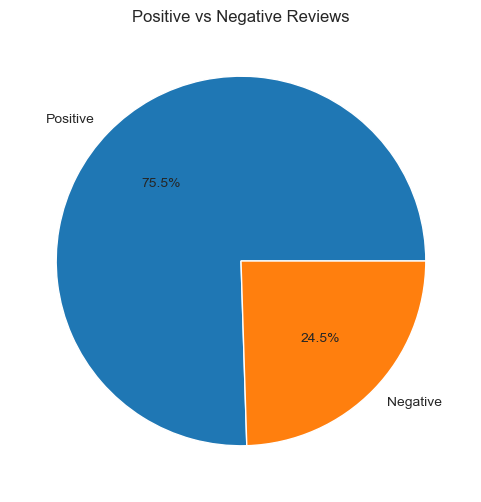

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(
    [positive_reviews, negative_reviews],
    labels=[
        "Positive",
        "Negative"
    ],
    autopct="%1.1f%%"
)
plt.title(
    "Positive vs Negative Reviews"
)
plt.show()

# Báo cáo Phân tích Tỷ lệ Đánh giá Tích cực và Tiêu cực (Positive vs Negative Reviews)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ tròn (Pie chart) hiển thị tỷ lệ phần trăm trực quan của các nhóm phản hồi.
* **Tiêu đề:** Positive vs Negative Reviews (Đánh giá tích cực so với tiêu cực).
* **Chú giải nhãn:** * **Positive (Tích cực):** Chiếm phần quạt màu xanh dương lớn.
  * **Negative (Tiêu cực):** Chiếm phần quạt màu cam.

---

## 2. Số liệu Chi tiết từ Biểu đồ
Biểu đồ ghi nhận tỷ lệ phân chia phản hồi từ khách hàng chính xác như sau:
* **Positive:** 75.5%
* **Negative:** 24.5%

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

* **Sức khỏe thương hiệu ở mức ổn định nhưng có tín hiệu rủi ro:**
  * Về mặt tích cực, đại đa số khách hàng (**75.5%**) đều để lại các phản hồi tốt (thường tương ứng với nhóm điểm 4 sao và 5 sao từ các phân tích trước). Điều này chứng tỏ doanh nghiệp vẫn giữ được lòng tin và sự hài lòng với 3/4 tệp người dùng của mình.
  * Tuy nhiên, tỷ lệ phản hồi tiêu cực chiếm tới **24.5%** (gần 1/4 tổng số đánh giá) là một con số **rất lớn và đáng báo động** đối với một nền tảng thương mại điện tử. Thông thường, một chỉ số tiêu cực vượt quá 15% đã là dấu hiệu cho thấy hệ thống vận hành đang gặp trục trặc nghiêm trọng.

* **Sự thống nhất logic với các chỉ số trước đó:**
  * Tỷ lệ 24.5% tiêu cực này phản ánh trọn vẹn tổng số lượng đánh giá 1, 2 và 3 sao ở báo cáo trước (vốn bị đẩy cao do lượng đánh giá 1 sao đột biến). 
  * **Kết luận hệ thống:** Cứ 4 khách hàng mua sắm trên sàn thì có 1 người không hài lòng. Khi kết nối chuỗi dữ liệu từ đầu đến giờ, nguyên nhân cốt lõi gây ra tỷ lệ tiêu cực cao này nhiều khả năng đến từ **khâu giao vận chậm trễ (8.11% đơn hàng bị trễ, nhiều đơn quá 1 tháng)** và **khủng hoảng chất lượng / dịch vụ của các ngành hàng lớn (điển hình là dòng sản phẩm chủ lực bed_bath_table nhận điểm trung bình dưới 4.0 sao)**. 
  * Doanh nghiệp cần lập tức rà soát và cải thiện hai lỗ hổng vận hành này để kéo giảm tỷ lệ 24.5% tiêu cực xuống mức an toàn (<10%).

In [92]:
rating_variability = (review_df.groupby("category_name")["review_score"].std().reset_index())
rating_variability.sort_values("review_score",ascending=False).head(10)

,category_name,review_score
62,security_and_services,2.121320
53,la_cuisine,1.732051
31,fashion_male_clothing,1.700989
47,home_comfort_2,1.644294
59,party_supplies,1.586209
35,fixed_telephony,1.554509
24,diapers_and_hygiene,1.551196
42,furniture_mattress_and_upholstery,1.539661
0,Unknown,1.537867
58,office_furniture,1.532888


# Báo cáo Phân tích Độ biến động Điểm đánh giá theo Danh mục (Top 10 Categories with Highest Rating Variability)

## 1. Tổng quan về Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python nhóm dữ liệu theo `category_name`, tính toán độ lệch chuẩn (`.std()`) trên biến `review_score`, sau đó sắp xếp giảm dần (`ascending=False`) và lấy 10 bản ghi đầu tiên bằng hàm `.head(10)`.
* **Bản chất chỉ số (Ý nghĩa toán học):** Độ lệch chuẩn (Standard Deviation) đo lường mức độ phân tán của dữ liệu xung quanh giá trị trung bình. Trong ngữ cảnh này, độ lệch chuẩn của `review_score` càng cao chứng tỏ danh mục đó nhận được lượng đánh giá **cực kỳ phân hóa, thiếu ổn định** (nhiều khách hàng chấm 5 sao, nhưng cũng có rất nhiều khách hàng chấm 1 sao cùng lúc).

---

## 2. Số liệu Chi tiết từ Mã nguồn
Bảng dữ liệu Pandas ghi nhận chính xác giá trị độ lệch chuẩn của Top 10 danh mục có mức độ phân hóa điểm đánh giá cao nhất:

1. **security_and_services:** 2.121320
2. **la_cuisine:** 1.732051
3. **fashion_male_clothing:** 1.700989
4. **home_comfort_2:** 1.644294
5. **party_supplies:** 1.586209
6. **fixed_telephony:** 1.554509
7. **diapers_and_hygiene:** 1.551196
8. **furniture_mattress_and_upholstery:** 1.539661
9. **Unknown:** 1.537867
10. **office_furniture:** 1.532888

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Khủng hoảng phân hóa tại ngành hàng security_and_services
* Danh mục **security_and_services** (An ninh & Dịch vụ) đứng đầu danh sách với độ lệch chuẩn vượt trội lên tới **2.12**. 
* Đây là một chỉ số cực kỳ cao đối với thang đo 5 sao, phản ánh một mô hình trải nghiệm khách hàng phân cực dữ dội (Polarized experience). Sản phẩm hoặc dịch vụ thuộc ngành này đang có xu hướng "được ăn cả, ngã về không" – hoặc là khách hàng cực kỳ hài lòng (5 sao), hoặc là họ gặp sự cố nghiêm trọng ảnh hưởng trực tiếp đến an ninh/quyền lợi và lập tức hạ xuống mức thấp nhất (1 sao).

### Bản chất của các ngành hàng nhận điểm đánh giá không ổn định
* Các ngành hàng tiếp theo như `la_cuisine` (1.73), `fashion_male_clothing` (1.70), và `home_comfort_2` (1.64) đều giữ mức biến động cao. 
* **Insight về chất lượng đồng đều:** Độ lệch chuẩn cao là tín hiệu cảnh báo rằng chất lượng sản phẩm giữa các nhà bán hàng (Sellers) trong cùng một ngành hàng đang **không đồng đều**. Khách hàng mua sắm ở các danh mục này đang phải đối mặt với rủi ro may rủi (chất lượng sản phẩm phụ thuộc quá nhiều vào từng đối tác cung ứng cụ thể, thay vì có một quy chuẩn chung ổn định).

### Mối liên hệ logic với nhóm có điểm trung bình thấp
* Đáng chú ý, hai danh mục **fashion_male_clothing** và **office_furniture** vừa nằm trong *Top 10 danh mục có điểm trung bình thấp nhất toàn sàn* ở báo cáo trước, vừa xuất hiện trong *Top 10 danh mục có độ lệch chuẩn cao nhất* ở báo cáo này.
* **Kết luận quản trị:** Sự kết hợp giữa "Điểm trung bình thấp" và "Độ lệch chuẩn cao" chứng tỏ hai ngành hàng này không hẳn là tệ toàn tập, mà chúng đang có một lượng đơn hàng lỗi/hỏng hóc quá lớn kéo tụt điểm số của những đơn hàng tốt xuống. Doanh nghiệp cần lập tức rà soát lại các nhà bán hàng có điểm số cực đoan phía dưới để thanh lọc hệ thống, nhằm đưa độ lệch chuẩn về mức an toàn (<1.0) và cải thiện trải nghiệm khách hàng.

# Correlation Analysis 

In [93]:
sales_full = pd.read_sql(
    "SELECT * FROM vw_sales_full",
    engine
)

sales_full.head()

,order_id,order_purchase_timestamp,customer_unique_id,customer_state,seller_state,category_name,price,freight_value,delivery_days,review_score
0,0036757472ece3dde52fd4bfd929c90e,2018-07-19 14:58:59,be03685420bb977861dda08f4b4088b3,SP,SP,office_furniture,136.99,66.04,21,2.0
1,0036887767dea4bd43b1a88cd0d9477a,2017-10-13 00:04:49,6d151e185615942c0bc8cd9373471ad1,MG,RJ,toys,399.99,23.64,10,5.0
2,00378c6c981f234634c0b9d6128df6dd,2018-02-02 19:39:46,cd2fd2a38f5903eb2a7377b548e0bfdd,SP,SP,sports_leisure,41.00,11.85,24,4.0
3,003822434f91204da0a51fe4cf2aba18,2018-06-13 14:10:54,250b38e3586d512ece3671470c5d5f6d,RJ,SP,perfumery,69.00,18.58,6,5.0
4,003822434f91204da0a51fe4cf2aba18,2018-06-13 14:10:54,250b38e3586d512ece3671470c5d5f6d,RJ,SP,perfumery,69.00,18.58,6,5.0


In [94]:
sales_full.isnull().sum()

order_id                      0
order_purchase_timestamp      0
customer_unique_id            0
customer_state                0
seller_state                  0
category_name                 0
price                         0
freight_value                 0
delivery_days                 0
review_score                827
dtype: int64

In [95]:
corr_df = sales_full.dropna(subset=["review_score" ])

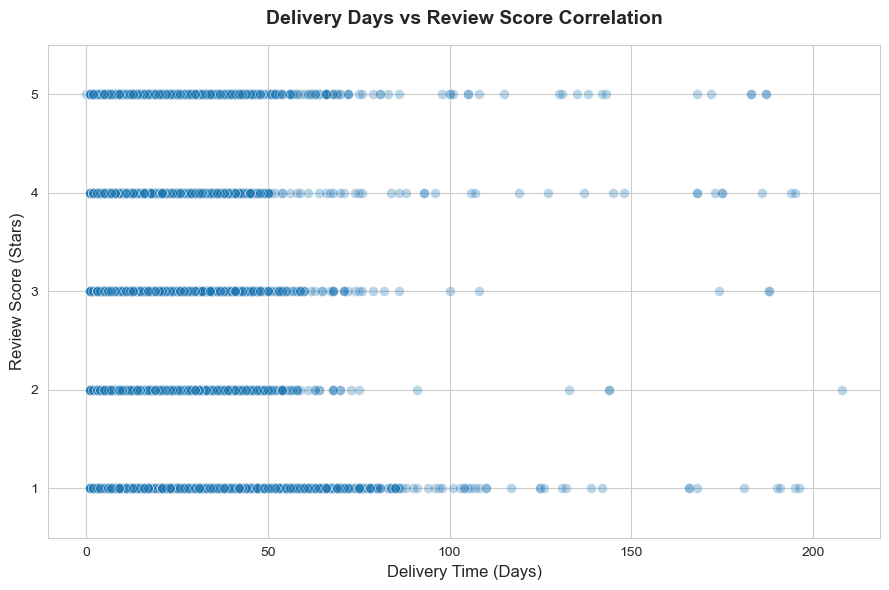

In [98]:
sns.set_style("whitegrid")
plt.figure(figsize=(9, 6))
ax = sns.scatterplot(
    data=corr_df,
    x="delivery_days",
    y="review_score",
    alpha=0.3,
    color="#1f77b4",
    s=50
)
plt.title("Delivery Days vs Review Score Correlation", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Delivery Time (Days)", fontsize=12)
plt.ylabel("Review Score (Stars)", fontsize=12)
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

# Báo cáo Phân tích Mối tương quan giữa Thời gian Giao hàng và Điểm đánh giá (Delivery Days vs Review Score Correlation)

## 1. Tổng quan về Biểu đồ
* **Loại biểu đồ:** Biểu đồ phân tán (Scatter plot) sử dụng các điểm tròn có độ trong suốt (alpha opacity) để biểu thị mật độ tập trung của dữ liệu.
* **Tiêu đề:** Delivery Days vs Review Score Correlation (Mối tương quan giữa số ngày giao hàng và điểm đánh giá).
* **Trục hoành (X-axis):** Delivery Time (Days) - Thời gian giao hàng tính bằng ngày (kéo dài từ 0 đến hơn 200 ngày).
* **Trục tung (Y-axis):** Review Score (Stars) - Điểm đánh giá phân lớp theo số sao nguyên (từ 1 sao đến 5 sao).

---

## 2. Các Quan sát Thống kê từ Biểu đồ

* **Mật độ tập trung ở khung thời gian ngắn (0 - 50 ngày):**
  * Các điểm dữ liệu tạo thành các dải màu xanh đậm đặc, liên tục dọc theo cả 5 mức sao trong khoảng thời gian giao hàng từ **0 đến 50 ngày**. Điều này tái khẳng định phần lớn đơn hàng của hệ thống được hoàn thành trong vòng dưới 2 tháng.
* **Độ thưa thớt ở giai đoạn sau (>50 ngày):**
  * Khi thời gian giao hàng vượt quá mốc 50 ngày và kéo dài đến 100 - 200 ngày, các chấm tròn bắt đầu thưa thớt dần, chuyển sang trạng thái mờ và tách rời nhau rõ rệt.
* **Sự xuất hiện của các Outliers (Điểm dị biệt) cực đoan:**
  * Biểu đồ ghi nhận một số đơn hàng có thời gian giao kỷ lục, lên tới **150 - 200 ngày**. Thậm chí có một đơn hàng ở mức 2 sao vượt mốc **200 ngày** (gần 7 tháng) mới giao tới nơi.

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Hiện tượng Overplotting (Ghi đè dữ liệu) do biến phân loại
* Vì trục Y là một biến phân loại rời rạc (Discrete/Categorical variable) chỉ nhận các giá trị nguyên từ 1 đến 5, biểu đồ xuất hiện hiện tượng các điểm dữ liệu bị chồng chập lên nhau rất nặng (Overplotting). Chúng ta nhìn thấy các đường thẳng tắp nằm ngang thay vì một đám mây điểm phân tán tự do.

### Xu hướng tương quan nghịch (Negative Correlation Pattern) ở các mốc thời gian lớn
Mặc dù hiện tượng chồng chập che khuất một phần mật độ, chúng ta vẫn bóc tách được một xu hướng thay đổi hành vi rất rõ nét khi nhìn về phía bên phải trục hoành (khi thời gian giao hàng bị kéo dài):
* **Ở mức 5 sao và 4 sao:** Khi thời gian giao hàng vượt mốc **75 ngày**, số lượng chấm tròn xuất hiện cực kỳ ít và trống trải. Khách hàng gần như từ chối chấm điểm tối đa nếu họ phải chờ đợi sản phẩm quá 2.5 tháng.
* **Ở mức 1 sao:** Ngược lại, dải chấm tròn của mức **1 sao** duy trì độ đậm và kéo dài liên tục, dày đặc nhất vượt qua mốc 100 ngày và rải đều cho tới tận mốc 200 ngày. 
* **Kết luận quản trị:** Biểu đồ này là một minh chứng trực quan đắt giá xác nhận **Thời gian giao hàng tỷ lệ nghịch với mức độ hài lòng của khách hàng**. Đơn hàng bị ngâm càng lâu (đặc biệt là nhóm trễ hạn nghiêm trọng nằm ở phần đuôi đuôi dài mà các biểu đồ trước đã đề cập) thì xác suất rơi thẳng xuống nhóm 1 sao càng lớn. Việc tối ưu hóa tốc độ giao vận không chỉ đơn thuần là cắt giảm chi phí, mà nó trực tiếp giữ cho điểm đánh giá của sàn không bị hủy hoại bởi các phản hồi 1 sao cực đoan.

In [99]:
corr_df[ ["delivery_days","review_score"]].corr()

,delivery_days,review_score
delivery_days,1.000000,-0.303812
review_score,-0.303812,1.000000


# Báo cáo Thống kê Định lượng: Hệ số Tương quan giữa Thời gian Giao hàng và Điểm đánh giá

## 1. Tổng quan về Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python trích xuất hai thuộc tính `delivery_days` (Số ngày giao hàng) và `review_score` (Điểm đánh giá) từ DataFrame `corr_df`, sau đó gọi hàm `.corr()` để tính toán ma trận hệ số tương quan Pearson.
* **Loại hiển thị:** Ma trận đối xứng (Correlation Matrix). Các giá trị trên đường chéo chính luôn bằng `1.000000` do một biến luôn tương quan hoàn hảo với chính nó.

---

## 2. Số liệu Chi tiết từ Mã nguồn
Giá trị hệ số tương quan toán học giữa hai biến được ghi nhận chính xác là:
* $r = -0.303812$ (Làm tròn: **-0.30**)

---

## 3. Nhận xét và Đánh giá Thống kê Chuyên sâu (Insights)

### Khẳng định mối tương quan nghịch (Negative Correlation)
* Hệ số tương quan mang **dấu âm** ($-0.30$) là minh chứng định lượng toán học chuẩn xác, củng cố cho xu hướng trực quan đã quan sát được từ biểu đồ phân tán (*Scatter plot*) trước đó. 
* **Ý nghĩa thực tế:** Khi biến `delivery_days` tăng lên (thời gian giao hàng kéo dài), biến `review_score` sẽ có xu hướng giảm đi (khách hàng chấm ít sao hơn) và ngược lại.

### Đánh giá mức độ tương quan (Correlation Strength)
* Theo thang đo tiêu chuẩn trong thống kê (đối với dữ liệu hành vi con người và khoa học xã hội), giá trị $|r| \approx 0.3$ đại diện cho một **mối tương quan nghịch ở mức độ trung bình (Moderate Negative Correlation)**.
* Chỉ số này chỉ ra rằng thời gian giao hàng không phải là yếu tố duy nhất quyết định điểm sao của khách hàng (vì còn phụ thuộc vào chất lượng sản phẩm, giá cả, thái độ phục vụ), nhưng nó đóng một vai trò cực kỳ quan trọng và có tác động dịch chuyển điểm số một cách rõ rệt.

### Giá trị ứng dụng trong Xây dựng Mô hình (Machine Learning & Analytics)
* **Kiểm định tính năng (Feature Selection):** Hệ số $-0.30$ cho thấy `delivery_days` là một tính năng mạnh (Strong feature), có ý nghĩa thống kê cao và bắt buộc phải giữ lại nếu bạn có ý định xây dựng các mô hình học máy để dự đoán điểm đánh giá của khách hàng (Review Score Prediction).
* **Bài toán Vận hành Doanh nghiệp:** Đây là con số biết nói giúp các nhà quản trị nhận ra rằng: Mỗi một ngày cắt giảm được trong khâu giao vận sẽ trực tiếp góp phần kéo chỉ số hài lòng của khách hàng lên cao hơn, giúp giảm thiểu đáng kể tỷ lệ nhận phản hồi tiêu cực trên toàn sàn.

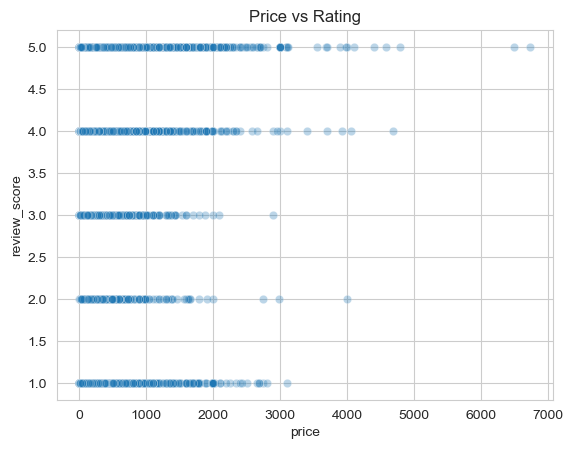

In [100]:
sns.scatterplot(data=corr_df,x="price",y="review_score",alpha=0.3)
plt.title("Price vs Rating")
plt.show()

In [101]:
corr_df[["price","review_score"]].corr()

,price,review_score
price,1.000000,0.003259
review_score,0.003259,1.000000


# Báo cáo Phân tích Mối tương quan giữa Giá sản phẩm và Điểm đánh giá (Price vs Rating Correlation)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python trích xuất hai thuộc tính `price` (Giá sản phẩm) và `review_score` (Điểm đánh giá) từ DataFrame `corr_df`, sau đó gọi hàm `.corr()` để tính toán hệ số tương quan Pearson giữa cặp biến này.
* **Loại biểu đồ:** Biểu đồ phân tán (Scatter plot) với các chấm tròn có độ trong suốt (alpha opacity) nhằm thể hiện mật độ tập trung của các bản ghi dữ liệu.
* **Tiêu đề:** Price vs Rating (Mối quan hệ giữa Giá cả và Điểm đánh giá).
* **Trục hoành (X-axis):** price - Giá sản phẩm (dao động từ mốc $0 đến gần $7,000).
* **Trục tung (Y-axis):** review_score - Điểm đánh giá phân lớp theo số sao nguyên (từ 1 sao đến 5 sao).

---

## 2. Số liệu Chi tiết từ Mã nguồn
Giá trị hệ số tương quan định lượng chính xác giữa hai biến được ghi nhận từ bảng console:
* Hệ số tương quan Pearson: **0.003259** (Tiến sát về mốc **0.00**)

---

## 3. Nhận xét và Đánh giá Thống kê Chuyên sâu (Insights)

### Trạng thái hoàn toàn không tương quan (Zero Correlation)
* Hệ số tương quan đạt giá trị gần như bằng không tuyệt đối (**0.003259**). Trong khoa học dữ liệu và thống kê, chỉ số này đưa ra một kết luận vô cùng đắt giá: **Giá bán của sản phẩm hoàn toàn không có bất kỳ mối liên hệ tuyến tính nào với việc khách hàng chấm điểm tốt hay tệ**.
* **Ý nghĩa hành vi:** Người tiêu dùng trên sàn TMĐT này không hề nương tay chấm nhiều sao hơn cho những món đồ đắt tiền (xa xỉ), và ngược lại họ cũng không khắt khe hơn với những sản phẩm giá rẻ. Mức độ hài lòng của họ phụ thuộc hoàn toàn vào chất lượng thực tế và trải nghiệm dịch vụ mang lại chứ không bị chi phối bởi số tiền ghi trên hóa đơn.

### Hiện tượng Overplotting và phân bổ hình học trên biểu đồ phân tán
* Do trục Y là một biến phân loại rời rạc (chỉ nhận các giá trị nguyên từ 1 đến 5), biểu đồ xuất hiện hiện tượng các điểm dữ liệu bị chồng chập lên nhau rất nặng (Overplotting), tạo thành 5 dải nằm ngang tắp dọc theo các mức sao.
* **Phân khúc giá phổ thông ($0 - $2,000):** Các chấm tròn tạo thành các dải màu xanh đậm đặc, liên tục dọc theo cả 5 mức sao trong khoảng giá từ $0 đến $2,000. Điều này phản ánh đây là khung giá tập trung tuyệt đại đa số sản phẩm được giao dịch trên sàn.
* **Phân khúc giá cao và Outliers cực đoan (> $3,000):** Phía bên phải trục hoành xuất hiện rải rác các điểm dị biệt có giá trị rất cao. Đáng chú ý, các sản phẩm siêu đắt đỏ ở mốc từ **$4,000 đến gần $7,000** xuất hiện tách biệt hẳn và chỉ rơi vào hai nhóm điểm: Hoặc là đạt điểm tối đa (**5 sao**, **4 sao**), hoặc là rơi thẳng xuống đáy (**1 sao**). Điều này cho thấy nhóm hàng xa xỉ khi đã xảy ra lỗi vận hành hoặc lỗi chất lượng sẽ khiến khách hàng phản ứng rất cực đoan.

---

## 4. Ý nghĩa đối với Quản trị Doanh nghiệp (Data-Driven Decisions)
* **Chiến lược định giá tự do (Pricing Strategy):** Doanh nghiệp có thể tự tin điều chỉnh chiến lược giá bán (tăng giá để tối ưu hóa biên lợi nhuận hoặc cấu hình lại các phân khúc giá) mà không cần quá lo sợ rằng hành động này sẽ trực tiếp làm sụt giảm điểm sao trung bình của gian hàng, miễn là giá trị thực tế của sản phẩm tương xứng với số tiền khách hàng bỏ ra.

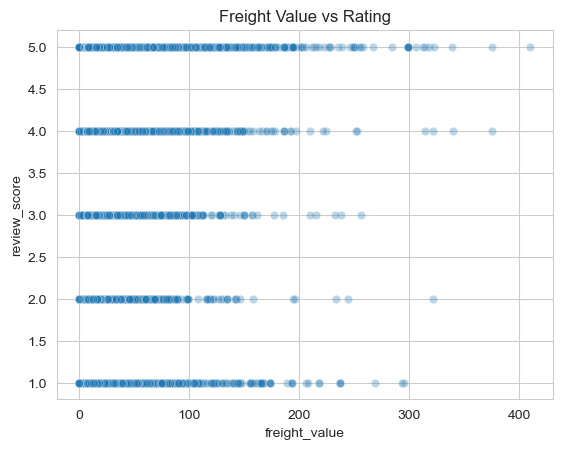

In [ ]:
sns.scatterplot(data=corr_df, x="freight_value",y="review_score", alpha=0.3)
plt.title("Freight Value vs Rating")
plt.show()

In [104]:
corr_df[["freight_value","review_score"]].corr()

,freight_value,review_score
freight_value,1.000000,-0.032863
review_score,-0.032863,1.000000


# Báo cáo Phân tích Mối tương quan giữa Chi phí Vận chuyển và Điểm đánh giá (Freight Value vs Review Score Correlation)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python trích xuất hai thuộc tính `freight_value` (Chi phí vận chuyển) và `review_score` (Điểm đánh giá) từ DataFrame `corr_df`, sau đó gọi hàm `.corr()` để tính toán hệ số tương quan Pearson.
* **Loại biểu đồ:** Biểu đồ phân tán (Scatter plot) với các điểm tròn có độ trong suốt (alpha opacity) nhằm thể hiện mật độ tập trung của các bản ghi dữ liệu.
* **Trục hoành (X-axis):** freight_value - Chi phí vận chuyển (dao động từ mốc 0 đến hơn 400 đơn vị tiền tệ).
* **Trục tung (Y-axis):** review_score - Điểm đánh giá phân lớp theo số sao nguyên (từ 1 sao đến 5 sao).

---

## 2. Số liệu Chi tiết từ Mã nguồn
Giá trị hệ số tương quan định lượng chính xác giữa hai biến được ghi nhận như sau:
* $r = -0.032863$ (Làm tròn: **-0.03**)

---

## 3. Nhận xét và Đánh giá Thống kê Chuyên sâu (Insights)

### Trạng thái gần như không tương quan (Near Zero Correlation)
* Hệ số tương quan mang giá trị âm nhưng tiến cực kỳ sát về mốc không ($-0.03$). Trong khoa học dữ liệu và thống kê, chỉ số này khẳng định **hai biến này gần như không có mối tương quan tuyến tính nào đáng kể**.
* **Ý nghĩa thực tế:** Việc phí vận chuyển đắt hay rẻ không phải là yếu tố trực tiếp chi phối tâm lý chấm điểm sao của người mua. Khách hàng không vì một đơn hàng có phí ship cao mà khắt khe hạ điểm số, và ngược lại họ cũng không nương tay chấm nhiều sao hơn chỉ vì được miễn phí hoặc giảm giá ship.

### Xu hướng phân bổ hình học trên biểu đồ phân tán
* Trực quan hóa từ biểu đồ *Freight Value vs Rating* phản ánh rất rõ nét kết luận thống kê trên. Các đám mây điểm dữ liệu tạo thành các dải nằm ngang dày đặc, phân bổ đồng đều trải dài từ mốc 0 đến 200 đơn vị trên cả 5 mức sao.
* Phía bên phải trục hoành xuất hiện một số điểm dị biệt (Outliers) có chi phí vận chuyển rất cao, kéo dài từ mốc 300 đến hơn 400 đơn vị. Các điểm này xuất hiện rải rác ở cả nhóm điểm tối đa (5 sao, 4 sao) lẫn nhóm điểm tối thiểu (1 sao), cho thấy chi phí vận chuyển cực đoan cũng không làm lệch xu hướng chấm điểm chung.

### Mối liên hệ chuỗi với bài toán Logistics
* **Bóc tách bản chất dữ liệu:** Mặc dù bản thân chi phí vận chuyển (`freight_value`) không tương quan với điểm số ($-0.03$), nhưng ở các phân tích trước chúng ta biết `freight_value` lại tương quan thuận với số ngày giao hàng (`delivery_days`: $0.22$) do các đơn hàng cồng kềnh hoặc giao xa có phí ship cao hơn. 
* **Kết luận quản trị:** Người tiêu dùng trên sàn TMĐT này không nhạy cảm với bản thân số tiền vận chuyển hiển thị trên hóa đơn, nhưng họ lại cực kỳ nhạy cảm với hệ quả của nó – chính là thời gian chờ đợi hàng đến tay (`delivery_days` tương quan $-0.30$ với điểm số). Do đó, chiến lược tối ưu không phải là cố gắng cắt giảm giá ship để làm hài lòng khách, mà là tập trung rút ngắn thời gian xử lý và vận chuyển đơn hàng.

In [105]:
corr_matrix = corr_df[
    [
        "price",
        "freight_value",
        "delivery_days",
        "review_score"
    ]
].corr()

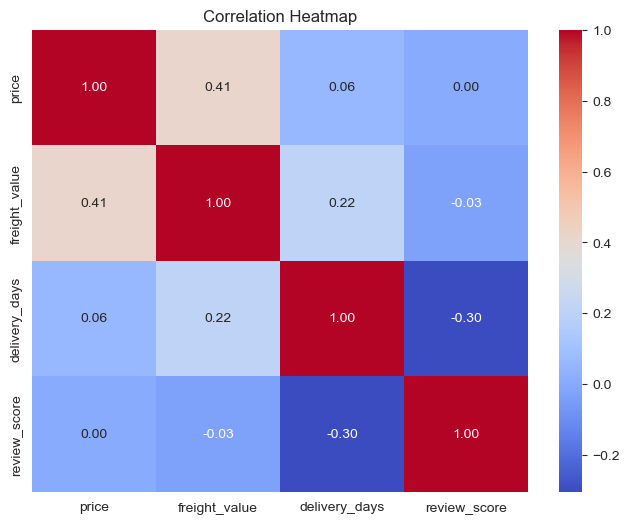

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f"
)
plt.title( "Correlation Heatmap")
plt.show()

# Báo cáo Phân tích Tổng hợp Ma trận Tương quan (Correlation Matrix & Heatmap Analysis)

## 1. Tổng quan về Biểu đồ và Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python thiết lập tính toán hệ số tương quan Pearson giữa 4 biến số cốt lõi: `price` (Giá sản phẩm), `freight_value` (Chi phí vận chuyển), `delivery_days` (Số ngày giao hàng), và `review_score` (Điểm đánh giá).
* **Loại biểu đồ:** * Biểu đồ phân tán (Scatter plot) trực quan hóa mối quan hệ phân phối giữa Giá và Số sao.
  * Bản đồ nhiệt (Heatmap) có hiển thị trực tiếp giá trị định lượng hệ số tương quan (`annot=True`) với dải màu `coolwarm` (Màu đỏ biểu thị tương quan đồng biến mạnh, màu xanh biểu thị tương quan nghịch biến mạnh).

---

## 2. Bảng Thống kê Hệ số Tương quan Tổng hợp
Dựa trên ma trận đối xứng từ bản đồ nhiệt, các chỉ số tương quan cụ thể giữa các cặp biến được ghi nhận chính xác như sau:

| Thuộc tính | price | freight_value | delivery_days | review_score |
| :--- | :---: | :---: | :---: | :---: |
| **price** | 1.00 | 0.41 | 0.06 | 0.00  |
| **freight_value** | 0.41 | 1.00 | 0.22 | -0.03 |
| **delivery_days** | 0.06 | 0.22 | 1.00 | -0.30 |
| **review_score** | 0.00 | -0.03 | -0.30 | 1.00 |

---

## 3. Nhận xét và Đánh giá Chuyên sâu (Insights)

### Nghịch lý hoàn toàn giữa Giá cả và Mức độ hài lòng (Price vs Review Score)
* Hệ số tương quan giữa `price` và `review_score` đạt giá trị toán học gần như bằng không tuyệt đối: **0.00** (chính xác từ bảng đơn lẻ là `0.003259`). 
* **Insight cốt lõi:** Con số này đưa ra một kết luận vô cùng đắt giá: **Giá bán của sản phẩm hoàn toàn không có bất kỳ mối liên hệ nào với việc khách hàng chấm điểm tốt hay tệ**. 
* Quan sát trên biểu đồ phân tán *Price vs Rating*, các đám mây điểm dày đặc kéo dài song song từ mức $0 đến $2,000 trên cả 5 mức sao. Dù sản phẩm có giá siêu rẻ hay là sản phẩm xa xỉ lên tới $4,000 - $6,000, xu hướng phân bổ điểm số vẫn y hệt nhau. Khách hàng không hề nương tay chấm nhiều sao hơn cho đồ đắt tiền, và ngược lại họ cũng không khắt khe hơn với đồ giá rẻ. Mức độ hài lòng phụ thuộc hoàn toàn vào giá trị thực tế và chất lượng trải nghiệm dịch vụ mang lại.

### Mối tương quan đồng biến giữa Giá sản phẩm và Phí vận chuyển (Price vs Freight Value)
* Cặp biến **price** và **freight_value** ghi nhận mối tương quan thuận ở mức độ trung bình khá với hệ số **0.41** (Màu ô chuyển sang sắc cam hồng nhạt).
* **Giải thích logic:** Thông thường các mặt hàng có giá trị cao (đồ điện tử, nội thất cao cấp, máy móc) sẽ có kích thước lớn, trọng lượng nặng, hoặc yêu cầu quy trình đóng gói bảo hiểm hàng hóa khắt khe hơn khi vận chuyển. Điều này đẩy chi phí vận chuyển (`freight_value`) tăng lên tỷ lệ thuận với giá trị gốc của mặt hàng.

### Mối liên hệ chuỗi giữa Logistics và Điểm số (Delivery Days vs Review Score)
* Ô màu xanh đậm nhất trên bản đồ nhiệt thuộc về cặp **delivery_days** và **review_score** với chỉ số **-0.30**. 
* Ma trận tổng hợp này một lần nữa đóng vai trò "chốt hạ" bài toán vận hành của sàn TMĐT: Trong khi Giá cả ($0.00$) hay Phí vận chuyển ($-0.03$) gần như đứng ngoài cuộc, thì **Thời gian giao hàng ($-0.30$) chính là yếu tố kỹ thuật duy nhất chi phối trực tiếp và mạnh mẽ đến điểm số đánh giá của người tiêu dùng**.

---

## 4. Định hướng Hành động cho Doanh nghiệp (Data-Driven Decisions)

1. **Ngừng lo lắng về việc tăng giá ảnh hưởng đến Review:** Doanh nghiệp có thể điều chỉnh chiến lược giá bán (Pricing strategy) tối ưu hóa lợi nhuận mà không cần quá lo sợ điều đó sẽ làm sụt giảm điểm sao trung bình của gian hàng, miễn là chất lượng sản phẩm được giữ vững.
2. **Dồn toàn lực tối ưu hóa chặng giao hàng (Last-mile Delivery):** Thay vì giảm giá sản phẩm để làm hài lòng khách hàng, hành động thực tế và mang lại hiệu quả cao nhất lúc này là đầu tư nâng cấp hệ thống kho bãi trung chuyển, tinh gọn quy trình đóng gói nhằm giảm số ngày giao hàng (`delivery_days`), trực tiếp kéo giảm tỷ lệ phản hồi tiêu cực trên toàn hệ thống.

In [107]:
corr_matrix["review_score"]\
.sort_values(ascending=False)

review_score     1.000000
price            0.003259
freight_value   -0.032863
delivery_days   -0.303812
Name: review_score, dtype: float64

# Báo cáo Thống kê Định lượng: Xếp hạng Mức độ Tương quan đối với Điểm đánh giá (Target Correlation Ranking)

## 1. Tổng quan về Dữ liệu
* **Nguồn dữ liệu:** Đoạn mã Python thực hiện trích xuất riêng cột `review_score` từ ma trận tương quan `corr_matrix`, sau đó sắp xếp các giá trị theo thứ tự giảm dần bằng hàm `.sort_values(ascending=False)`.
* **Mục đích xử lý:** Kỹ thuật này giúp cô lập biến mục tiêu (Target variable) nhằm xếp hạng và xác định nhanh chóng những yếu tố nào có tác động mạnh nhất (bất kể đồng biến hay nghịch biến) đến mức độ hài lòng của khách hàng.

---

## 2. Số liệu Chi tiết từ Mã nguồn
Kết quả phân tích mối tương quan tuyến tính với `review_score` thu được chính xác như sau:
* **review_score:** 1.000000 *(Tương quan hoàn hảo với chính nó)*
* **price:** 0.003259
* **freight_value:** -0.032863
* **delivery_days:** -0.303812

---

## 3. Nhận xét và Đánh giá (Insights)

* **Xác định biến độc lập có sức ảnh hưởng tối cao (Dominant Feature):**
  * Đầu ra của bảng console hiển thị một thứ tự phân bậc rất rõ ràng. Trong số tất cả các đặc trưng (features) được đưa vào phân tích, **delivery_days** là biến duy nhất có giá trị hệ số vượt trội hẳn về mặt độ lớn ($|-0.303812|$). 
  * Điều này khẳng định thời gian vận chuyển là yếu tố kỹ thuật mang tính quyết định, chi phối trực tiếp đến việc khách hàng sẽ chấm bao nhiêu sao cho đơn hàng.

* **Sự mờ nhạt của các yếu tố chi phí tài chính (Financial Features):**
  * Cả hai biến liên quan đến tiền bạc là `price` (Giá sản phẩm: 0.003259) và `freight_value` (Phí vận chuyển: -0.032863) đều có hệ số tiến sát về mốc 0. 
  * **Ý nghĩa hành vi:** Sự biến động của giá cả hay phí ship đắt/rẻ gần như không tạo ra bất kỳ tác động tuyến tính đáng kể nào tới tâm lý chấm điểm của người mua. Khách hàng trên sàn TMĐT này đánh giá chất lượng dịch vụ dựa trên trải nghiệm thực tế (hàng đến nhanh hay chậm) hơn là việc họ phải chi trả bao nhiêu tiền cho món hàng đó.

---

## 4. Điểm cộng về mặt Kỹ thuật Xử lý Dữ liệu (Technical Review)
* **Ứng dụng hiệu quả cho bài toán Lựa chọn Đặc trưng (Feature Selection):**
  * Việc bóc tách một vector tương quan từ ma trận tổng và sắp xếp giảm dần là một bước cực kỳ chuẩn chỉnh trong giai đoạn Tiền xử lý dữ liệu (Data Preprocessing). 
  * Kết quả này cung cấp một bằng chứng định lượng vững chắc để loại bỏ các biến nhiễu, ít giá trị và dồn sự tập trung vào việc tối ưu hóa biến `delivery_days` khi xây dựng các mô hình hồi quy hoặc dự báo hành vi người dùng.